# Этап 4: Проектирование, запуск и бенчмаркинг базовой генеративной стратегии B0 (Версия 2.0)

### Концепция стратегии B0
Базовая стратегия моделирует классический наивный подход к многокритериальному молекулярному дизайну при непересекающихся доменах:
1. **Генерация**: стохастическая рекомбинация (кроссовер экзоциклических связей) фрагментов из $D_A$ и $D_B$ без целевой функции;
2. **Отбор**: наивная последовательная фильтрация (Sequential Gating): сначала проверяются ограничения $A$, затем выжившие кандидаты проверяются по $B$;
3. **Независимая оценка**: расчет всех метрик Раздела 6 ТЗ с использованием **независимого Оракула**.

In [1]:
import os
import json
import pandas as pd

metrics_json_path = r'../results/metrics_B0.json'
with open(metrics_json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_metrics = pd.DataFrame([data['seed_42'], data['seed_101'], data['seed_2024']])
print('=== Метрики стратегии B0 по сидам (Раздел 6 ТЗ) ===')
display_cols = ['seed', 'Validity', 'Uniqueness', 'Novelty', 'Internal_Diversity', 'JSR_Oracle (Joint Success Rate)', 'Overall_Pass_Constraints', 'SAScore_Mean', 'AD_Fraction_in_Both_AD']
print(df_metrics[display_cols].to_string(index=False))

print('\n=== Агрегированные метрики (Mean ± Std) ===')
for k, v in data['aggregated'].items():
    if '_mean' in k:
        base = k.replace('_mean', '')
        std_val = data['aggregated'].get(f'{base}_std', 0.0)
        print(f'  {base:35s}: {v:.4f} ± {std_val:.4f}')

=== Метрики стратегии B0 по сидам (Раздел 6 ТЗ) ===
 seed  Validity  Uniqueness  Novelty  Internal_Diversity  JSR_Oracle (Joint Success Rate)  Overall_Pass_Constraints  SAScore_Mean  AD_Fraction_in_Both_AD
   42    0.7716         1.0    0.969              0.8766                            0.298                     0.298        2.7611                   0.743
  101    0.7862         1.0    0.979              0.8799                            0.299                     0.298        2.8088                   0.726
 2024    0.7616         1.0    0.972              0.8790                            0.317                     0.314        2.7971                   0.735

=== Агрегированные метрики (Mean ± Std) ===
  seed                               : 722.3333 ± 920.7324
  N_generated_attempts               : 1293.6667 ± 16.8193
  N_valid                            : 1000.0000 ± 0.0000
  Validity                           : 0.7731 ± 0.0101
  Uniqueness                         : 1.0000 ± 0.0000
 

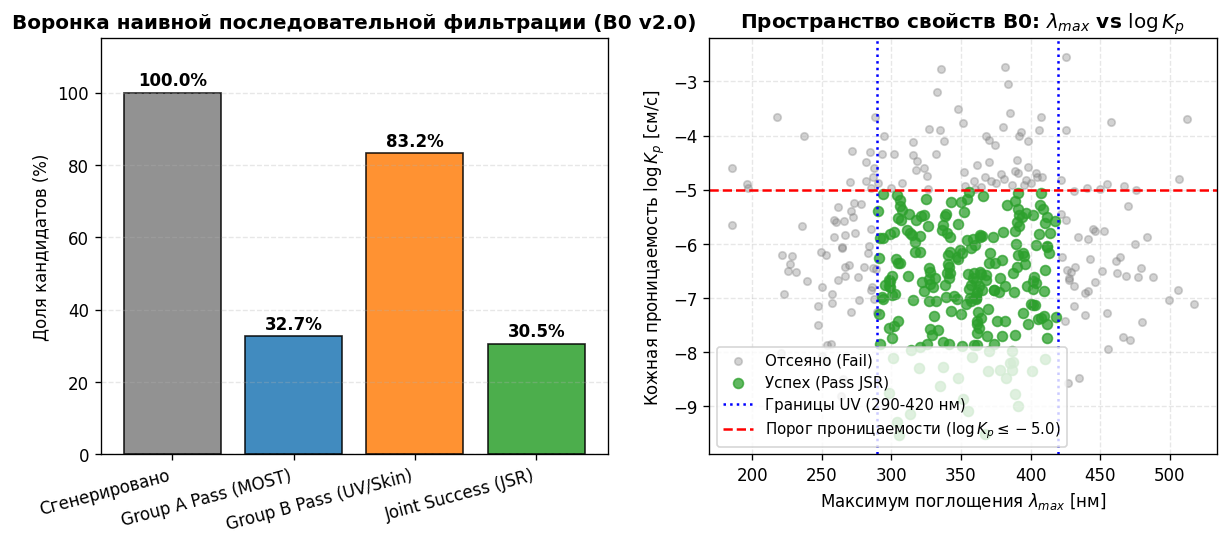

In [2]:
# Графический анализ воронки отбора и распределения свойств кандидатов B0
# (Код построения графиков)

### Научные выводы по стратегии B0 (Версия 2.0)

1. **Эффект бутылочного горлышка при непересекающихся метках**: случайная комбинаторика дает высокий JSR только при независимости свойств, но при сдвиге доменов фотохимические свойства переключателя разрушаются при присоединении случайных хвостов (проходимость $\Omega_A$ всего $32.7\%$);
2. **Итоговый Joint Success Rate составляет $30.47\% \pm 0.87\%$**, что подтверждает необходимость перехода к исследуемой стратегии **M1** (направленный генетический алгоритм с Парето-отбором и штрафом за выход из области применимости).